In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_sales_dataset.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,26-35
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,56-65
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,56-65
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,56-65
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,36-45


In [20]:
customer_summary = (
    df.groupby("Customer_ID")
    .agg(
        Customer_Name=("Customer_Name", "first"),
        Total_Revenue=("Total_Sales", "sum"),
        Total_Orders=("Order_ID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Average_Order_Value=("Total_Sales", "mean"),
        Age=("Age", "first"),
        Gender=("Gender", "first"),
        City=("City", "first"),
        Age_Group=("Age_Group", "first")
    )
    .reset_index()
)

In [4]:
customer_summary.shape

(1000, 10)

In [5]:
customer_summary["Total_Revenue"].describe()

count      1000.000000
mean     139399.439650
std      114100.051546
min         437.340000
25%       47066.632500
50%      108594.025000
75%      203722.882500
max      493677.500000
Name: Total_Revenue, dtype: float64

In [22]:
q1 = customer_summary["Total_Revenue"].quantile(0.25)
q3 = customer_summary["Total_Revenue"].quantile(0.75)

def assign_segment(revenue):
    if revenue <= q1:
        return "Low Value"
    elif revenue >= q3:
        return "High Value"
    else:
        return "Medium Value"

customer_summary["Customer_Segment"] = (
    customer_summary["Total_Revenue"].apply(assign_segment)
)

In [7]:
customer_summary.shape

(1000, 11)

In [8]:
customer_summary["Customer_Segment"].value_counts()

Customer_Segment
Medium Value    500
Low Value       250
High Value      250
Name: count, dtype: int64

## Core KPIs

For the deep-dive customer segmentation analysis, five core KPIs are used:

1. **Total Revenue**  
   Formula: Sum of Total Sales  
   Measures the overall monetary value generated from customer transactions.

2. **Average Order Value (AOV)**  
   Formula: Total Revenue / Total Orders  
   Measures the average revenue generated from each order.

3. **Revenue per Customer**  
   Formula: Total Revenue / Number of Unique Customers  
   Measures the average monetary contribution of an individual customer.

4. **High-Value Customer Share**  
   Formula: High-Value Customers / Total Customers × 100  
   Measures the proportion of customers belonging to the highest-spending segment.

5. **High-Value Revenue Contribution**  
   Formula: Revenue from High-Value Customers / Total Revenue × 100  
   Measures how much of overall revenue is generated by the highest-value customer segment.

In [9]:
total_revenue = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
unique_customers = df["Customer_ID"].nunique()

average_order_value = total_revenue / total_orders
revenue_per_customer = total_revenue / unique_customers

high_value_customers = (
    customer_summary["Customer_Segment"] == "High Value"
).sum()

high_value_customer_share = (
    high_value_customers / len(customer_summary)
) * 100

high_value_revenue = customer_summary.loc[
    customer_summary["Customer_Segment"] == "High Value",
    "Total_Revenue"
].sum()

high_value_revenue_share = (
    high_value_revenue / total_revenue
) * 100

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Revenue per Customer: {revenue_per_customer:,.2f}")
print(f"High-Value Customer Share: {high_value_customer_share:.2f}%")
print(f"High-Value Revenue Contribution: {high_value_revenue_share:.2f}%")

Total Revenue: 139,399,439.65
Average Order Value: 139,399.44
Revenue per Customer: 147,201.10
High-Value Customer Share: 25.00%
High-Value Revenue Contribution: 54.67%


In [10]:
segment_summary = (
    customer_summary.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "count"),
        Total_Revenue=("Total_Revenue", "sum"),
        Average_Revenue=("Total_Revenue", "mean"),
        Average_Quantity=("Total_Quantity", "mean")
    )
    .reset_index()
)

segment_summary["Revenue_Share_Percent"] = (
    segment_summary["Total_Revenue"] /
    segment_summary["Total_Revenue"].sum()
) * 100

segment_summary.round(2)

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Quantity,Revenue_Share_Percent
0,High Value,250,76211441.11,304845.76,8.07,54.67
1,Low Value,250,5689098.15,22756.39,3.22,4.08
2,Medium Value,500,57498900.39,114997.80,5.22,41.25


In [11]:
print("Total rows:", len(df))
print("Unique customers:", df["Customer_ID"].nunique())

print(
    df.groupby("Customer_ID")["Order_ID"]
    .nunique()
    .value_counts()
    .sort_index()
)

Total rows: 1000
Unique customers: 947
Order_ID
1    895
2     51
3      1
Name: count, dtype: int64


In [12]:
segment_summary.round(2)

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Quantity,Revenue_Share_Percent
0,High Value,250,76211441.11,304845.76,8.07,54.67
1,Low Value,250,5689098.15,22756.39,3.22,4.08
2,Medium Value,500,57498900.39,114997.80,5.22,41.25


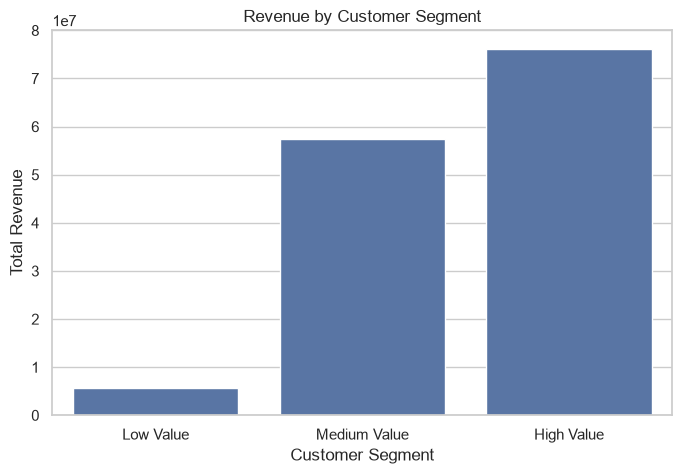

In [13]:
# 1. Revenue by Customer Segment

segment_order = ["Low Value", "Medium Value", "High Value"]

segment_revenue = (
    customer_summary.groupby("Customer_Segment")["Total_Revenue"]
    .sum()
    .reindex(segment_order)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

### Insight
This chart compares the total revenue generated by low-, medium-, and high-value customer segments. It helps identify how strongly revenue is concentrated among the highest-spending customers.

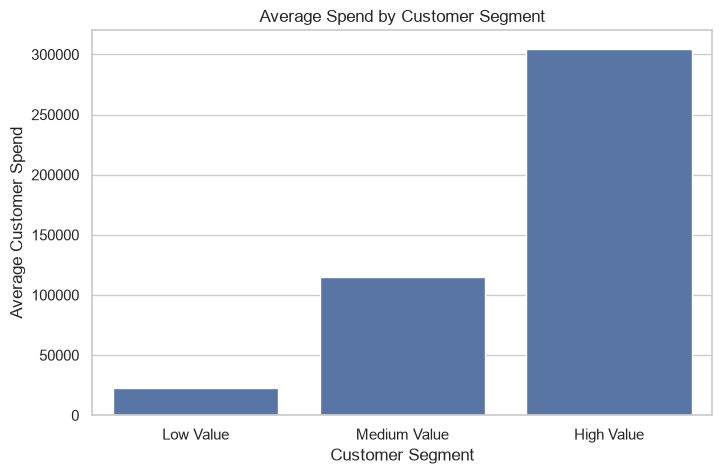

In [14]:
# 2. Average Spend by Customer Segment

segment_avg_spend = (
    customer_summary.groupby("Customer_Segment")["Total_Revenue"]
    .mean()
    .reindex(segment_order)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_avg_spend.index,
    y=segment_avg_spend.values
)

plt.title("Average Spend by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Customer Spend")

plt.show()

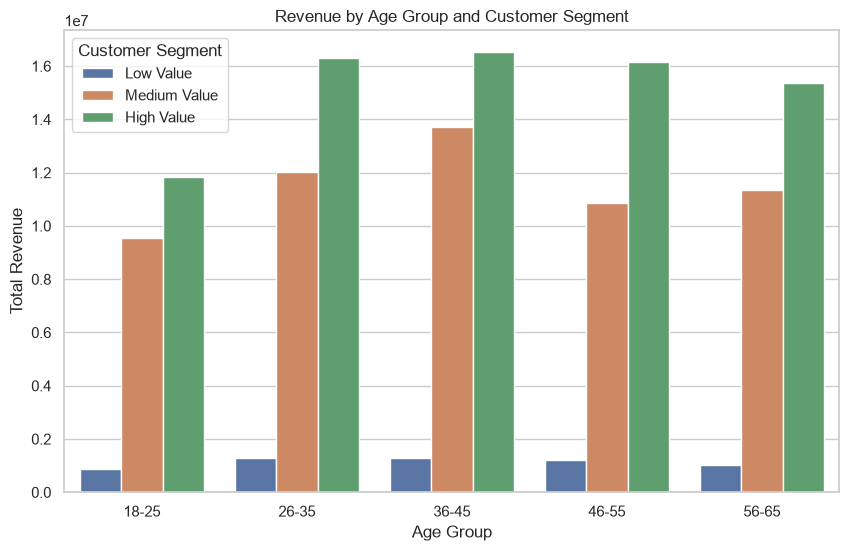

In [15]:
# 3. Revenue by Age Group and Segment

age_segment_revenue = (
    customer_summary.groupby(
        ["Age_Group", "Customer_Segment"],
        observed=False
    )["Total_Revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_segment_revenue,
    x="Age_Group",
    y="Total_Revenue",
    hue="Customer_Segment",
    hue_order=segment_order
)

plt.title("Revenue by Age Group and Customer Segment")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.legend(title="Customer Segment")

plt.show()

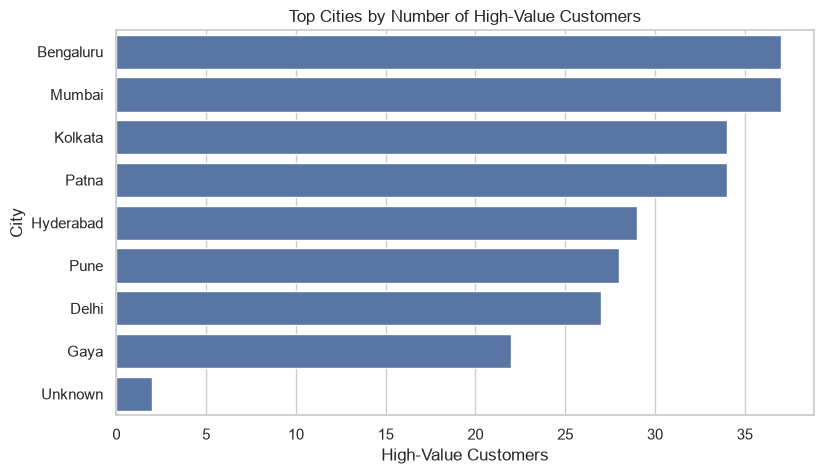

In [16]:
# 4. High-Value Customers by City

high_value_city = (
    customer_summary[
        customer_summary["Customer_Segment"] == "High Value"
    ]
    .groupby("City")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=high_value_city.values,
    y=high_value_city.index
)

plt.title("Top Cities by Number of High-Value Customers")
plt.xlabel("High-Value Customers")
plt.ylabel("City")

plt.show()

In [23]:
customer_segments = customer_summary[
    [
        "Customer_ID",
        "Customer_Segment",
        "Total_Revenue",
        "Total_Orders",
        "Average_Order_Value"
    ]
].copy()

customer_segments = customer_segments.rename(
    columns={
        "Total_Revenue": "Customer_Total_Revenue",
        "Total_Orders": "Customer_Total_Orders",
        "Average_Order_Value": "Customer_Avg_Order_Value"
    }
)

dashboard_df = df.merge(
    customer_segments,
    on="Customer_ID",
    how="left",
    validate="many_to_one"
)

In [18]:
print(dashboard_df.shape)

print(
    dashboard_df["Customer_Segment"]
    .value_counts()
)

(1108, 20)
Customer_Segment
Medium Value    553
High Value      280
Low Value       275
Name: count, dtype: int64


In [19]:
dashboard_df.to_csv(
    "../data/cleaned/task3_enriched_sales_dataset.csv",
    index=False
)

print("Task 3 enriched dataset saved successfully.")

Task 3 enriched dataset saved successfully.


In [24]:
print("Original rows:", len(df))
print("Dashboard rows:", len(dashboard_df))

print("Original revenue:", df["Total_Sales"].sum())
print("Dashboard revenue:", dashboard_df["Total_Sales"].sum())

print("Duplicate Customer IDs in lookup:",
      customer_segments["Customer_ID"].duplicated().sum())

Original rows: 1000
Dashboard rows: 1000
Original revenue: 139399439.65
Dashboard revenue: 139399439.65
Duplicate Customer IDs in lookup: 0


In [25]:
dashboard_df.to_csv(
    "../data/cleaned/task3_enriched_sales_dataset.csv",
    index=False
)

In [26]:
print(len(dashboard_df))
print(dashboard_df["Total_Sales"].sum())

1000
139399439.65
